# **FASHION MNIST**

In [1]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.5 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Expand dims for CNN
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print("Shape:", x_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape: (60000, 28, 28, 1)


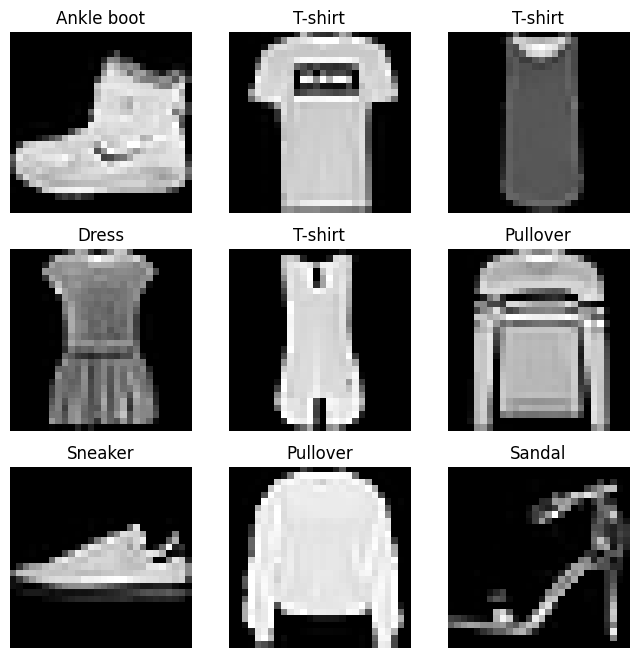

In [4]:
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

In [5]:
def build_model(hp):
    model = keras.Sequential()

    model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
    model.add(layers.MaxPooling2D())
    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D())
    model.add(layers.Flatten())

    # 🔥 Tune Dense Units
    units = hp.Int('dense_units', min_value=32, max_value=512, step=32)
    model.add(layers.Dense(units, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    # 🔥 Tune Learning Rate
    lr = hp.Choice('learning_rate', values=[0.01, 0.001, 0.0001])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [6]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [7]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='fashion_tuning',
    project_name='fashion'
)

tuner.search(x_train, y_train,
             epochs=10,
             validation_split=0.2,
             callbacks=[early_stop])

Trial 5 Complete [00h 00m 45s]
val_accuracy: 0.8705000281333923

Best val_accuracy So Far: 0.9160000085830688
Total elapsed time: 00h 04m 03s


In [8]:
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best Dense Units:", best_hp.get('dense_units'))
print("Best Learning Rate:", best_hp.get('learning_rate'))

Best Dense Units: 384
Best Learning Rate: 0.001


In [9]:
best_model = tuner.hypermodel.build(best_hp)

history = best_model.fit(
    x_train, y_train,
    epochs=15,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7719 - loss: 0.6264 - val_accuracy: 0.8761 - val_loss: 0.3452
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8884 - loss: 0.3013 - val_accuracy: 0.8917 - val_loss: 0.2982
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9068 - loss: 0.2474 - val_accuracy: 0.9018 - val_loss: 0.2650
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9195 - loss: 0.2126 - val_accuracy: 0.9067 - val_loss: 0.2605
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9322 - loss: 0.1825 - val_accuracy: 0.9135 - val_loss: 0.2428
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9426 - loss: 0.1545 - val_accuracy: 0.9163 - val_loss: 0.2335
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9508 - loss: 0.1302 - val_accuracy: 0.9097 - val_loss: 0.2691
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9574 - loss: 0.1149 - 

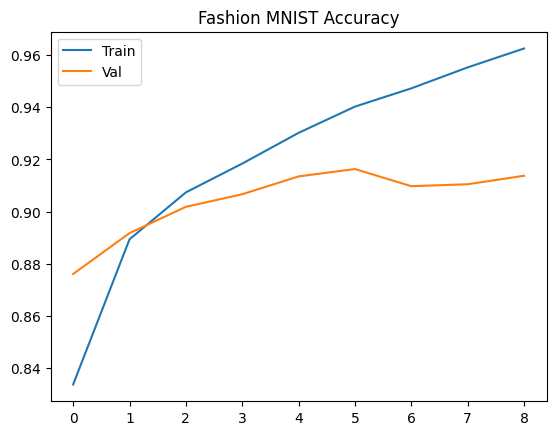

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Fashion MNIST Accuracy")
plt.legend(['Train','Val'])
plt.show()

# **2.CIFAR-100**

In [15]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data()

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (50000, 32, 32, 3)
Testing shape: (10000, 32, 32, 3)


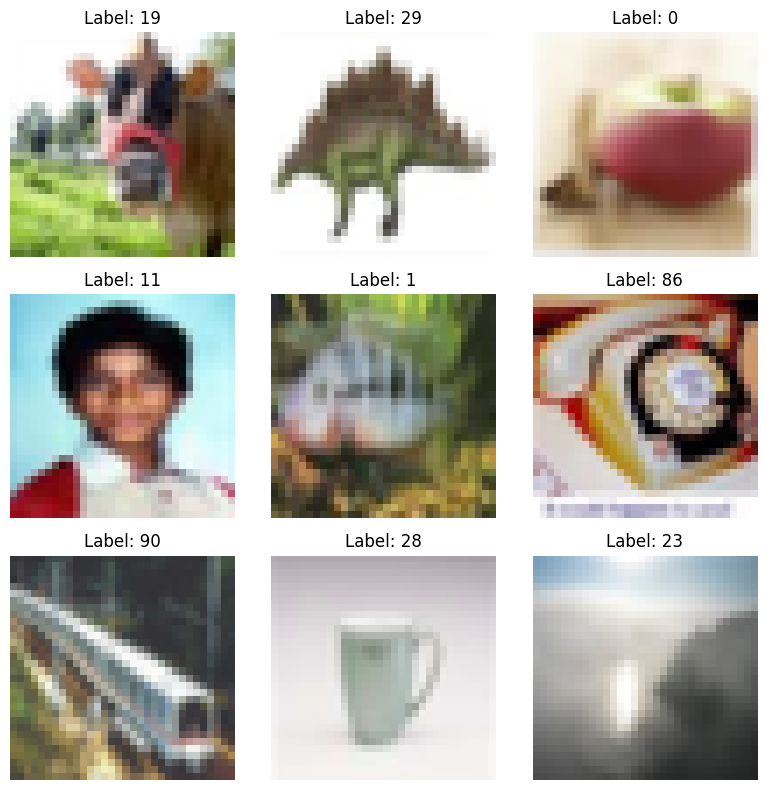

In [16]:
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title("Label: " + str(y_train[i][0]))
    plt.axis('off')
plt.tight_layout()
plt.show()

In [17]:
def build_model(hp):
    model = keras.Sequential()

    model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
    model.add(layers.MaxPooling2D())

    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D())

    model.add(layers.Conv2D(128, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D())

    model.add(layers.Flatten())

    # 🔥 Tune Dense Units (32 - 512)
    units = hp.Int('dense_units', min_value=32, max_value=512, step=32)
    model.add(layers.Dense(units, activation='relu'))

    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(100, activation='softmax'))  # 100 classes

    # 🔥 Tune Learning Rate
    lr = hp.Choice('learning_rate', values=[0.01, 0.001, 0.0001])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [18]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [19]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='cifar100_tuning',
    project_name='cifar100'
)

In [21]:
tuner.search(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Trial 5 Complete [00h 00m 48s]
val_accuracy: 0.010900000110268593

Best val_accuracy So Far: 0.3506999909877777
Total elapsed time: 00h 05m 34s


In [22]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best Dense Units:", best_hp.get('dense_units'))
print("Best Learning Rate:", best_hp.get('learning_rate'))

Best Dense Units: 480
Best Learning Rate: 0.001


In [23]:
best_model = tuner.hypermodel.build(best_hp)

history = best_model.fit(
    x_train, y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.0407 - loss: 4.3119 - val_accuracy: 0.1358 - val_loss: 3.6598
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1450 - loss: 3.5880 - val_accuracy: 0.2071 - val_loss: 3.2709
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2086 - loss: 3.2503 - val_accuracy: 0.2578 - val_loss: 3.0152
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2542 - loss: 3.0240 - val_accuracy: 0.2973 - val_loss: 2.8397
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2832 - loss: 2.8564 - val_accuracy: 0.3061 - val_loss: 2.7906
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3157 - loss: 2.7005 - val_accuracy: 0.3272 - val_loss: 2.6529
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3376 - loss: 2.5850 - val_accuracy: 0.3361 - val_loss: 2.6385
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3533 - loss: 2.5038 -

In [24]:
test_loss, test_acc = best_model.evaluate(x_test, y_test)
print("\n🎯 Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3925 - loss: 2.4338

🎯 Test Accuracy: 0.38749998807907104


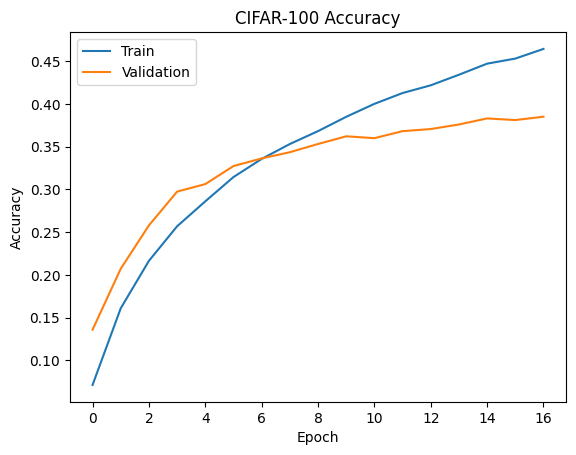

In [25]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("CIFAR-100 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Validation'])
plt.show()

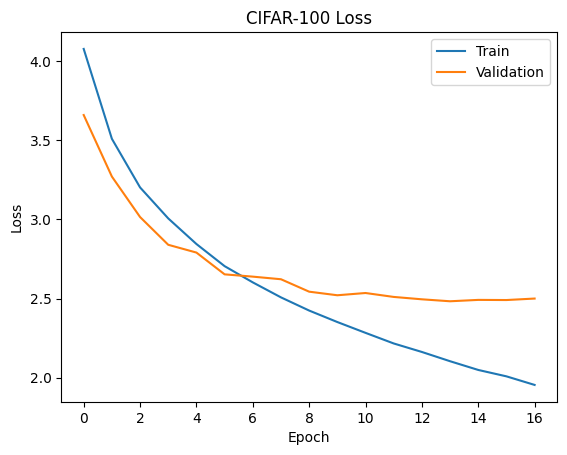

In [26]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("CIFAR-100 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train','Validation'])
plt.show()

# **3 — CHEST X-RAY**

In [27]:
from google.colab import files
files.upload()  # upload kaggle.json

!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [01:02<00:00, 25.5MB/s]
100% 2.29G/2.29G [01:02<00:00, 39.2MB/s]


In [28]:
train_dir = "chest_xray/train"
val_dir = "chest_xray/val"
test_dir = "chest_xray/test"

train_gen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

val_gen = keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

test_data = val_gen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


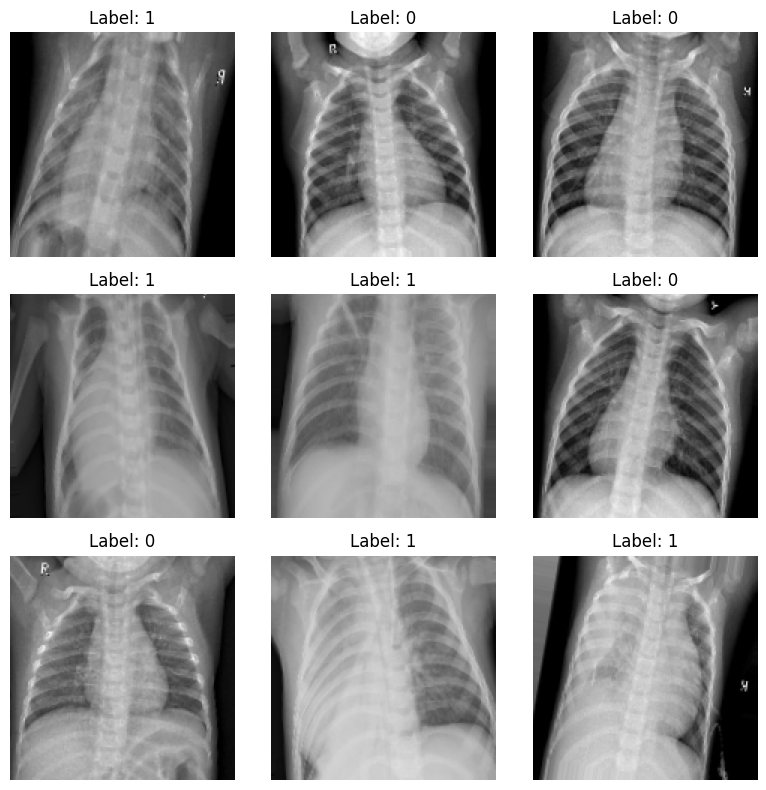

In [29]:
images, labels = next(train_data)

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title("Label: " + str(int(labels[i])))
    plt.axis('off')
plt.tight_layout()
plt.show()

In [30]:
def build_model(hp):
    model = keras.Sequential()

    model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)))
    model.add(layers.MaxPooling2D())

    model.add(layers.Conv2D(64,(3,3),activation='relu'))
    model.add(layers.MaxPooling2D())

    model.add(layers.Conv2D(128,(3,3),activation='relu'))
    model.add(layers.MaxPooling2D())

    model.add(layers.Flatten())

    # 🔥 Tune Dense Units
    units = hp.Int('dense_units', 32, 512, step=32)
    model.add(layers.Dense(units, activation='relu'))

    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(1, activation='sigmoid'))

    # 🔥 Tune Learning Rate
    lr = hp.Choice('learning_rate', [0.01, 0.001, 0.0001])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [31]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [32]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='xray_tuning',
    project_name='pneumonia'
)

In [34]:
tuner.search(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=[early_stop]
)

Trial 5 Complete [00h 04m 31s]
val_accuracy: 0.5

Best val_accuracy So Far: 0.9375
Total elapsed time: 00h 32m 30s


In [35]:
best_hp = tuner.get_best_hyperparameters(1)[0]

print("✅ Best Dense Units:", best_hp.get('dense_units'))
print("✅ Best Learning Rate:", best_hp.get('learning_rate'))

✅ Best Dense Units: 224
✅ Best Learning Rate: 0.0001


In [36]:
best_model = tuner.hypermodel.build(best_hp)

history = best_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 414ms/step - accuracy: 0.7589 - loss: 0.5169 - val_accuracy: 0.6875 - val_loss: 0.5649
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 66s 403ms/step - accuracy: 0.9122 - loss: 0.2281 - val_accuracy: 0.8750 - val_loss: 0.3769
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 400ms/step - accuracy: 0.9349 - loss: 0.1744 - val_accuracy: 0.8125 - val_loss: 0.4571
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 66s 406ms/step - accuracy: 0.9241 - loss: 0.1785 - val_accuracy: 0.8125 - val_loss: 0.5253
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 399ms/step - accuracy: 0.9409 - loss: 0.1561 - val_accuracy: 0.7500 - val_loss: 0.6674


In [37]:
test_loss, test_acc = best_model.evaluate(test_data)
print("\n Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 179ms/step - accuracy: 0.8252 - loss: 0.4378

 Test Accuracy: 0.8717948794364929


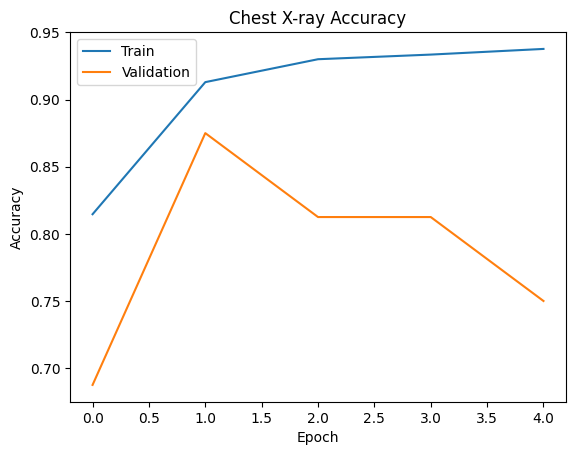

In [38]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Chest X-ray Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Validation'])
plt.show()

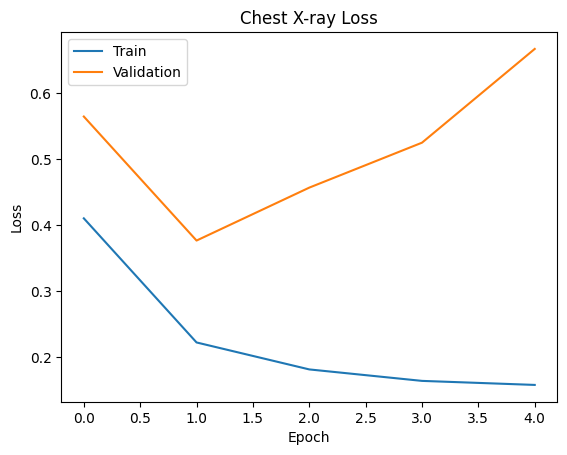

In [39]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Chest X-ray Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train','Validation'])
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 200ms/step


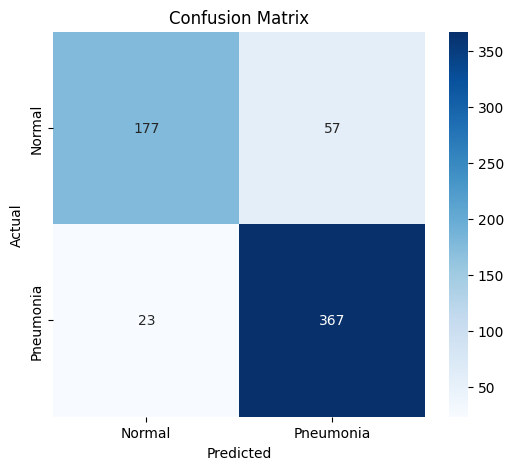

In [43]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
predictions = best_model.predict(test_data)
pred_labels = (predictions > 0.5).astype(int)

cm = confusion_matrix(test_data.classes, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [44]:
print(classification_report(test_data.classes, pred_labels,
                            target_names=['Normal','Pneumonia']))

              precision    recall  f1-score   support

      Normal       0.89      0.76      0.82       234
   Pneumonia       0.87      0.94      0.90       390

    accuracy                           0.87       624
   macro avg       0.88      0.85      0.86       624
weighted avg       0.87      0.87      0.87       624

